# A sparse family, end to end

One corpus of sparse rows goes through everything the database does with
it: create a family, insert rows with facets, look a row up by its key,
build the index, search, filter a search, add rows without rebuilding,
measure recall against exact answers, build a neighbour graph, fit a UMAP
map and draw it, place new rows on the map, cluster, replace a row, and
delete one.

The corpus is 2,000 rows over 20,000 dimensions in 20 planted topics.
Each row has 32 non-zeros; 30 of them come from a pool of 36 dimensions
that its topic owns, so rows of one topic are neighbours by construction
and every result below can be checked against the plant.

What you need: the UltraDim wheel and `matplotlib`. The UMAP fit and the
clustering need a GPU (Metal on macOS, Vulkan on Linux); everything
before them runs without one. The whole example runs in about a minute.

This file is a Python script and a notebook. As a script it writes the
map to `sparse_map.png`. Open it as a notebook with
`jupytext --to ipynb 02_sparse_worked_example.py` and the map is shown
inline as well.

In [1]:
import json
import math
import tempfile
import time

import numpy as np

import ultradim

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


def in_notebook():
    """True inside a Jupyter kernel, False when run as a script."""
    try:
        from IPython import get_ipython
        return type(get_ipython()).__name__ == "ZMQInteractiveShell"
    except ImportError:
        return False


IN_NOTEBOOK = in_notebook()
if IN_NOTEBOOK:
    from IPython.display import Image as NotebookImage, display

D_RAW = 20_000       # width of the sparse space
N_ROWS = 2_000
N_TOPICS = 20
NNZ = 32             # non-zeros per row
POOL, SHARED = 36, 30
MAP_PNG = "sparse_map.png"


def rpc(db, rpc_name, **fields):
    return json.loads(db.call_json(rpc_name, json.dumps(fields)))


def hits(response):
    """A search answer as (row id, score) pairs."""
    return [(r["id"]["point_id_options"]["Num"], round(r["score"], 4))
            for r in response["result"]]


print("wheel version:", ultradim.__version__, "| notebook:", IN_NOTEBOOK)

wheel version: 0.4.0 | notebook: True


## 1. The corpus

A sparse row is two lists: the indices of its non-zero dimensions, in
ascending order, and their values. The values here are unit length, so a
cosine between two rows is their dot product. `max_nnz_per_row` is set
from the data with ten percent of headroom; the family refuses a row
wider than that.

In [2]:
def planted_rows(seed=5):
    """Sparse rows as {"indices": [...], "values": [...]}, values unit length."""
    rng = np.random.default_rng(seed)
    topics = [rng.choice(D_RAW, POOL, replace=False) for _ in range(N_TOPICS)]
    rows = []
    for i in range(N_ROWS):
        topic = topics[i % N_TOPICS]
        idx = np.unique(np.concatenate([
            rng.choice(topic, SHARED, replace=False),
            rng.choice(D_RAW, NNZ - SHARED, replace=False),
        ]))
        vals = np.abs(rng.standard_normal(len(idx)).astype(np.float32))
        vals /= np.linalg.norm(vals)
        order = np.argsort(idx)
        rows.append({"indices": [int(x) for x in idx[order]],
                     "values": [float(x) for x in vals[order]]})
    return rows


rows = planted_rows()
max_nnz = math.ceil(1.10 * max(len(r["indices"]) for r in rows))
print(f"corpus: {N_ROWS} rows x {D_RAW} dims, max_nnz_per_row={max_nnz}")
print("row 0:", rows[0]["indices"][:6], "...", [round(v, 3) for v in rows[0]["values"][:6]], "...")

corpus: 2000 rows x 20000 dims, max_nnz_per_row=36
row 0: [20, 452, 974, 2314, 2618, 2973] ... [0.024, 0.211, 0.072, 0.36, 0.089, 0.237] ...


## 2. Create the family and insert the rows

`sparse_substrate=True` makes a sparse family. Rows go in with row ids
that start at 0 and continue without gaps, and each row may carry
facets: named fields that a search can filter on. Two facets are set
here, a `content_key` string that names the row and an integer `topic`.

In [3]:
path = tempfile.mkdtemp(prefix="ultradim_sparse_")
db = ultradim.UltraDim(path)
name = "papers"

rpc(db, "CreateUltradimV23Collection",
    name=name, source_dim=D_RAW, projection_dim=128,
    seeds=[11, 22, 33, 44], sparse_substrate=True, max_nnz_per_row=max_nnz)

facets = [{"fields": {
    "content_key": {"kind": {"KeywordValue": f"paper-{i:04d}"}},
    "topic": {"kind": {"IntValue": i % N_TOPICS}},
}} for i in range(N_ROWS)]
up = rpc(db, "UpsertUltradimV23Points", name=name,
         batch={"row_ids": list(range(N_ROWS)),
                "sparse_vectors": rows, "facets": facets})
print("upsert:", up["points_inserted"], "rows")

upsert: 2000 rows


## 3. Look a row up by its key

The `content_key` facet is an identity. A row can be found by it as soon
as it is inserted, before any index exists, and the answer says whether
the key was found and which row id holds it.

In [4]:
hit = rpc(db, "GetUltradimV23RowByContentKey", name=name, content_key="paper-0007")
miss = rpc(db, "GetUltradimV23RowByContentKey", name=name, content_key="paper-9999")
print("lookup paper-0007:", hit["found"], "row", hit["row_id"],
      "| paper-9999:", miss["found"])

lookup paper-0007: True row 7 | paper-9999: False


## 4. Make the family searchable

The index is built once. `window=1` settles each record as it is
indexed, which is the setting to use when rows will be replaced later
and the replacement must be searchable at once.

In [5]:
t0 = time.time()
built = rpc(db, "BuildUltradimV23TrellisIndex", name=name, window=1)
print(f"build: {built['graph_nodes']} nodes in {time.time() - t0:.1f} s")

build: 2000 nodes in 3.2 s


## 5. Search, and search with a filter

The query is row 0's own vector, with row 0 excluded from the answer.
Every hit is a row of topic 0, because that is where row 0's neighbours
were planted. The scores are true cosines against the stored rows.

The second search adds a facet filter, `topic = 0`. The answer is the
same rows, and `candidates_pooled` shows the filter did its work before
scoring, not after.

In [6]:
found = rpc(db, "UltradimV23TrellisTemplateSearch", name=name,
            sparse_query=rows[0], top_k=5, exclude_ids=[0])
print("top-5 for row 0:", hits(found))
print("  same topic:", all(i % N_TOPICS == 0 for i, _ in hits(found)),
      "| candidates:", found["stats"]["candidates_pooled"])

filtered = rpc(db, "UltradimV23TrellisTemplateSearch", name=name,
               sparse_query=rows[0], top_k=5, exclude_ids=[0],
               template_filter={"must": [{"field": "topic", "cond": {"MatchInt": 0}}]})
print("filtered top-5 :", hits(filtered),
      "| candidates:", filtered["stats"]["candidates_pooled"])

top-5 for row 0: [(520, 0.6218), (60, 0.6011), (460, 0.5988), (1920, 0.5831), (280, 0.5667)]
  same topic: True | candidates: 108
filtered top-5 : [(520, 0.6218), (60, 0.6011), (460, 0.5988), (1920, 0.5831), (280, 0.5667)] | candidates: 100


## 6. Add rows without rebuilding

Five more rows go in, copies of rows 0 to 4 under new keys. They are
searchable at once. A search with row 1's vector now finds row 1 and its
copy, row 2001, both at a cosine of 1.

In [7]:
more = [{"fields": {"content_key": {"kind": {"KeywordValue": f"paper-{N_ROWS + i:04d}"}}}}
        for i in range(5)]
rpc(db, "UpsertUltradimV23Points", name=name,
    batch={"row_ids": list(range(N_ROWS, N_ROWS + 5)),
           "sparse_vectors": rows[:5], "facets": more})
again = rpc(db, "UltradimV23TrellisTemplateSearch", name=name,
            sparse_query=rows[1], top_k=3)
print("after 5 more rows, top-3 for row 1:", hits(again))

after 5 more rows, top-3 for row 1: [(1, 1.0), (2001, 1.0), (1421, 0.65)]


## 7. Measure recall against exact answers

`CreateSparseOracles` computes the exact top 10 for 50 query rows by
brute force over the whole family and stores it. `MeasureRecall` runs the
same queries through the index and reports the fraction of exact
neighbours it returned, with the query latency. This is the number that
tells you whether the index can be trusted on this data.

`active_seeds` chooses how much of the index a query uses. Fewer seeds is
faster; the recall beside each setting says what that costs.

In [8]:
oracle = rpc(db, "CreateSparseOracles", name=name,
             query_ids=list(range(50)), top_k=10)
print("oracle:", oracle["n_queries"], "queries over", oracle["n_committed"], "rows")
for seeds in ([11, 22, 33, 44], [11, 22]):
    rec = rpc(db, "MeasureRecall", name=name, oracle_path=oracle["artifact_path"],
              k=10, exclude_self=True, use_template=True, active_seeds=seeds)
    print(f"recall@10 with {len(seeds)} seeds: {rec['recall_at_k']:.4f}"
          f"  p50 {rec['p50_ms']:.2f} ms  p95 {rec['p95_ms']:.2f} ms")

oracle: 50 queries over 2005 rows
recall@10 with 4 seeds: 1.0000  p50 1.36 ms  p95 1.53 ms
recall@10 with 2 seeds: 1.0000  p50 1.34 ms  p95 1.49 ms


## 8. A neighbour graph and a map

A UMAP map is fitted on a neighbour graph, so the graph comes first:
`k=15` neighbours per row over every row in the family. The fit is
deterministic given `umap_seed`, and runs for 50 epochs here to keep the
example short. The positions are read back with
`GetUltradimV23UmapEmbedding`, two numbers per row, and drawn with each
row coloured by its planted topic. Twenty groups should be visible.

knn graph: umapknn-aeb1969013af643f rows 2005
umap fit: umap-01d4c31c2b0f91d2 epochs 50
map written to sparse_map.png


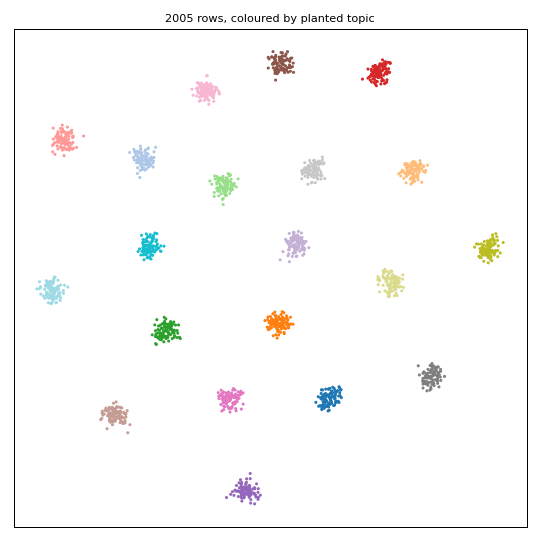

In [9]:
graph = rpc(db, "BuildUltradimV23KnnGraph", name=name, k=15, append=False)
print("knn graph:", graph["graph_id"], "rows", graph["rows_processed"])
fit = rpc(db, "FitUltradimV23Umap", name=name, graph_id=graph["graph_id"],
          n_components=2, n_neighbors=15, n_epochs=50, umap_seed=7, deterministic=True)
print("umap fit:", fit["umap_id"], "epochs", fit["epochs_run"])

emb = rpc(db, "GetUltradimV23UmapEmbedding", name=name, umap_id=fit["umap_id"],
          limit=8192, offset_ordinal=0)
nc = emb["n_components"]
xy = np.array(emb["embeddings"]).reshape(-1, nc)
colour = [(i % N_TOPICS) for i in range(len(xy))]
fig, ax = plt.subplots(figsize=(6, 6), dpi=90)
ax.scatter(xy[:, 0], xy[:, 1], s=6, c=colour, cmap="tab20", linewidths=0)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{len(xy)} rows, coloured by planted topic", fontsize=9)
fig.tight_layout()
fig.savefig(MAP_PNG)
plt.close(fig)
print("map written to", MAP_PNG)
if IN_NOTEBOOK:
    display(NotebookImage(filename=MAP_PNG))

## 9. Place new rows on the map

`TransformUltradimV23Umap` puts rows onto an existing map without
refitting it. Rows 0 and 1 are placed here and come out at their own
fitted positions, which is the check that placement agrees with the fit. On a
stream, this is how each day's arrivals are put on yesterday's map.

In [10]:
placed = rpc(db, "TransformUltradimV23Umap", name=name, umap_id=fit["umap_id"],
             sparse_queries=rows[:2])
print("rows 0 and 1, fitted :", [[round(float(v), 2) for v in xy[i]] for i in range(2)])
print("rows 0 and 1, placed :",
      [[round(x, 2) for x in placed["embeddings"][i:i + 2]] for i in range(0, 4, 2)])

rows 0 and 1, fitted : [[1.1, -2.62], [-7.47, 8.0]]
rows 0 and 1, placed : [[1.09, -2.66], [-7.44, 7.9]]


## 10. Cluster

Spherical k-means into four clusters, at the rows' full width. Beside the
cluster sizes the answer carries `mean_log10_p_real`, the log of the
probability that a clustering this tight would arise on data with no
structure. A large negative number means the clusters are real. The
score is corrected for width, so it can be compared across families of
different widths.

In [11]:
cl = rpc(db, "ClusterUltradimV23", name=name, num_clusters=4, max_cycles=25)
print("cluster sizes:", cl["cluster_sizes"], "cycles", cl["cycles"],
      "mean_log10_p_real", round(cl["mean_log10_p_real"], 1))

cluster sizes: [515, 410, 588, 492] cycles 25 mean_log10_p_real -473.4


## 11. Replace a row

Row 7's vector is replaced with row 8's. The replacement is a new row
with a new row id; the old row is retired, not overwritten, and the
`content_key` follows the replacement. A search with row 8's vector now
finds row 8 and the replacement, both at a cosine of 1.

In [12]:
rep = rpc(db, "ReplaceUltradimV23Point", name=name, old_row_id=7, sparse_vector=rows[8])
now = rpc(db, "GetUltradimV23RowByContentKey", name=name, content_key="paper-0007")
print("replace row 7 -> new row", rep["new_row_id"],
      "| paper-0007 now resolves to row", now["row_id"])
print("search with row 8's vector:", hits(rpc(
    db, "UltradimV23TrellisTemplateSearch", name=name, sparse_query=rows[8], top_k=3)))

replace row 7 -> new row 2005 | paper-0007 now resolves to row 2005
search with row 8's vector: [(8, 1.0), (2005, 1.0), (248, 0.7246)]


## 12. Delete a row

The replacement is deleted. A second delete of the same row id reports
that it was already deleted rather than failing. The key no longer
resolves, and the search with row 8's vector finds row 8 alone. Row ids
are never reused.

In [13]:
gone = rpc(db, "DeleteUltradimV23Point", name=name, row_id=rep["new_row_id"])
twice = rpc(db, "DeleteUltradimV23Point", name=name, row_id=rep["new_row_id"])
after = rpc(db, "GetUltradimV23RowByContentKey", name=name, content_key="paper-0007")
print("delete:", gone["success"], "| second delete already_deleted:",
      twice["was_already_deleted"], "| paper-0007 found:", after["found"])
print("search with row 8's vector:", hits(rpc(
    db, "UltradimV23TrellisTemplateSearch", name=name, sparse_query=rows[8], top_k=3)))

delete: True | second delete already_deleted: True | paper-0007 found: False
search with row 8's vector: [(8, 1.0), (248, 0.7246), (208, 0.6885)]
